# Football Market Intelligence — Odds Analysis

**Notebook 02: EPL Over/Under 2.5 Goals — Odds Structure, Market Efficiency & Calibration**

This notebook is a focused deep-dive into the *odds data* itself — how prices are structured, where bookmakers agree or disagree, and whether Pinnacle's closing market is well-calibrated enough to serve as a probability reference. Covers five EPL seasons (2019/20 – 2023/24) with four bookmakers: Pinnacle (PIN), Bet365 (B365), Market Average (AVG), Market Maximum (MAX).

| Section | Question |
|---------|----------|
| 2 | Which bookmakers have data, and how complete is coverage? |
| 3 | How are over and under odds distributed across bookmakers? |
| 4 | How does the margin (overround) compare — sharp vs recreational? |
| 5 | Where do Pinnacle and Bet365 disagree most, and does it matter? |
| 6 | Is Pinnacle's market efficient across all probability deciles? |
| 7 | Which bookmaker is better calibrated: PIN or B365? |
| 8 | How has market pricing evolved season-by-season? |
| 9 | When the market says "unlikely over", how often does it actually go over? |

---
> **Data note:** All odds are closing-price snapshots sourced from Football-Data.co.uk (FDCO). No live or in-play odds are used. All analysis is retrospective on completed historical matches.

---
## 1. Setup

In [1]:
import sys
import warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

from src.analysis.descriptive import (
    season_summary,
    bookmaker_margin_by_season,
    implied_prob_summary,
    sharp_vs_recreational_margin,
    calibration_data,
    overall_calibration_metrics,
    bookmaker_prob_divergence,
    high_divergence_matches,
    odds_distribution_by_bookmaker,
    odds_by_season,
    pinnacle_efficiency_check,
)
from src.utils.db import run_query
from src.utils.config import DB_PATH

# ── Plotting style ───────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.05)
PALETTE   = sns.color_palette('tab10')
SHARP_COL = PALETTE[0]   # blue   — Pinnacle
REC_COL   = PALETTE[1]   # orange — Bet365
AVG_COL   = PALETTE[2]   # green  — Market Average
MAX_COL   = PALETTE[4]   # purple — Market Maximum
NEUTRAL   = PALETTE[7]   # grey

BK_COL = {
    'Pinnacle':       SHARP_COL,
    'Bet365':         REC_COL,
    'Market Average': AVG_COL,
    'Market Maximum': MAX_COL,
}
BK_ORDER = ['Pinnacle', 'Market Average', 'Market Maximum', 'Bet365']

FIG_DIR = '../reports/figures'

print('Setup complete. DB_PATH:', DB_PATH)

Setup complete. DB_PATH: C:\Users\USER\Documents\Python Projects\bet-intelligence\data\db\bet_intelligence.duckdb


In [2]:
# Verify database connection and row counts
try:
    db_tables = run_query(
        "SELECT table_name FROM information_schema.tables WHERE table_schema = 'main' ORDER BY table_name",
        db_path=DB_PATH,
    )
    print('Tables present:', db_tables['table_name'].tolist())
except Exception as exc:
    print(f'DB connection failed: {exc}')
    raise

for tbl in ['matches', 'odds_snapshots', 'bookmakers', 'teams']:
    n = run_query(f'SELECT COUNT(*) AS n FROM {tbl}', db_path=DB_PATH).iloc[0, 0]
    print(f'  {tbl:<20s}: {n:,} rows')

Tables present: ['backtest_bets', 'bookmakers', 'competitions', 'engineered_features', 'injuries', 'lineups', 'matches', 'model_predictions', 'odds_snapshots', 'team_match_stats', 'teams']
  matches             : 1,900 rows
  odds_snapshots      : 7,590 rows
  bookmakers          : 5 rows
  teams               : 26 rows


In [3]:
# Load all descriptive-module outputs once and cache for the rest of the notebook
print('Loading data from descriptive module...')

df_season      = season_summary()
df_margins     = bookmaker_margin_by_season()
df_prob_sum    = implied_prob_summary()
df_sharp_rec   = sharp_vs_recreational_margin()
df_divergence  = bookmaker_prob_divergence()
df_high_div    = high_divergence_matches(min_divergence=0.05)
df_odds_dist   = odds_distribution_by_bookmaker()
df_odds_season = odds_by_season()
df_efficiency  = pinnacle_efficiency_check()

metrics_pin  = overall_calibration_metrics('PIN')
metrics_b365 = overall_calibration_metrics('B365')
metrics_avg  = overall_calibration_metrics('AVG')
cal_pin      = calibration_data('PIN',  n_bins=10)
cal_b365     = calibration_data('B365', n_bins=10)

# Full raw snapshot with match context — used throughout
df_raw = run_query("""
    SELECT
        o.match_id,
        o.odds_over,
        o.odds_under,
        o.implied_prob_over,
        o.implied_prob_under,
        o.margin,
        bk.name        AS bookmaker,
        bk.short_code,
        bk.is_sharp,
        m.season,
        m.over_25::INTEGER AS outcome,
        m.total_goals
    FROM odds_snapshots o
    JOIN bookmakers bk ON o.bookmaker_id = bk.bookmaker_id
    JOIN matches    m  ON o.match_id     = m.match_id
    WHERE o.odds_over IS NOT NULL
""", db_path=DB_PATH)

print(f'Raw odds rows  : {len(df_raw):,}')
print(f'Unique matches : {df_raw["match_id"].nunique():,}')
print(f'Bookmakers     : {sorted(df_raw["bookmaker"].unique())}')
print(f'Seasons        : {sorted(df_raw["season"].unique())}')
print('All data loaded successfully.')

Loading data from descriptive module...
Raw odds rows  : 7,590
Unique matches : 1,900
Bookmakers     : ['Bet365', 'Market Average', 'Market Maximum', 'Pinnacle']
Seasons        : ['2019/20', '2020/21', '2021/22', '2022/23', '2023/24']
All data loaded successfully.


---
## 2. Odds Data Coverage

Before any analysis, confirm which bookmakers contribute data, how many matches each covers, and whether there are systematic gaps.

In [4]:
coverage = run_query("""
    SELECT
        bk.name                                                       AS bookmaker,
        bk.short_code,
        CASE WHEN bk.is_sharp THEN 'Sharp' ELSE 'Recreational' END   AS market_type,
        COUNT(DISTINCT o.match_id)                                    AS matches_covered,
        ROUND(
            COUNT(DISTINCT o.match_id) * 100.0
            / (SELECT COUNT(*) FROM matches), 1
        )                                                             AS coverage_pct,
        SUM(CASE WHEN o.odds_over  IS NOT NULL THEN 1 ELSE 0 END)    AS n_over_prices,
        SUM(CASE WHEN o.odds_under IS NOT NULL THEN 1 ELSE 0 END)    AS n_under_prices,
        ROUND(AVG(o.odds_over),  3)                                   AS mean_odds_over,
        ROUND(AVG(o.odds_under), 3)                                   AS mean_odds_under
    FROM odds_snapshots o
    JOIN bookmakers bk ON o.bookmaker_id = bk.bookmaker_id
    GROUP BY bk.name, bk.short_code, bk.is_sharp
    ORDER BY matches_covered DESC
""", db_path=DB_PATH)

print('=== Odds Data Coverage ===')
print(coverage.to_string(index=False))

=== Odds Data Coverage ===
     bookmaker short_code  market_type  matches_covered  coverage_pct  n_over_prices  n_under_prices  mean_odds_over  mean_odds_under
Market Maximum        MAX Recreational             1900         100.0         1900.0          1900.0           1.863            2.257
Market Average        AVG Recreational             1900         100.0         1900.0          1900.0           1.796            2.163
        Bet365       B365 Recreational             1899          99.9         1899.0          1899.0           1.799            2.160
      Pinnacle        PIN        Sharp             1891          99.5         1891.0          1891.0           1.832            2.195


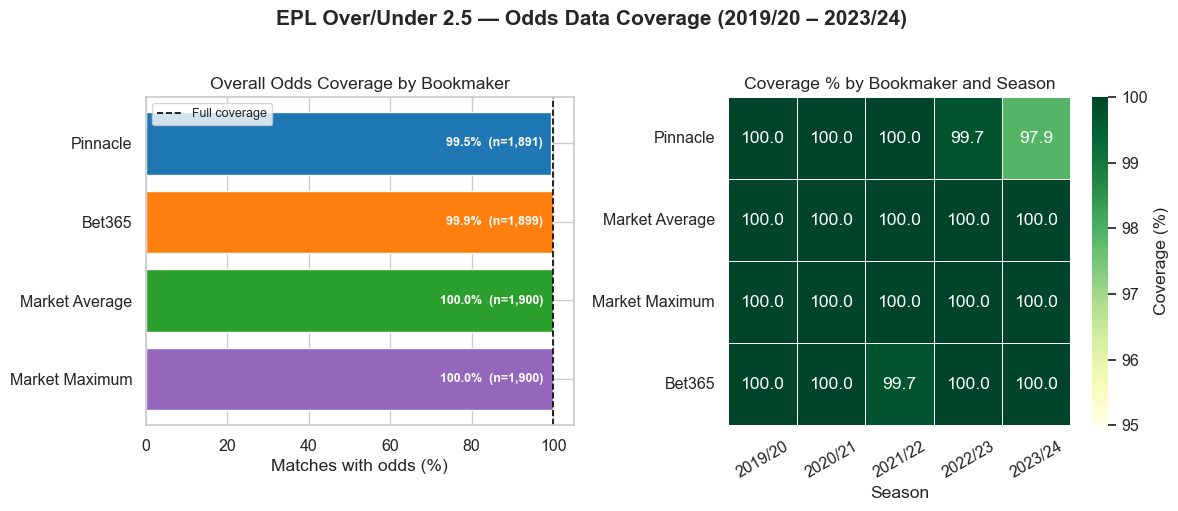

In [5]:
# Season-level coverage breakdown
coverage_season = run_query("""
    SELECT
        m.season,
        bk.name AS bookmaker,
        COUNT(DISTINCT o.match_id)                             AS matches_with_odds,
        ROUND(
            COUNT(DISTINCT o.match_id) * 100.0
            / COUNT(DISTINCT m2.match_id), 1
        )                                                      AS coverage_pct
    FROM matches m
    LEFT JOIN odds_snapshots o  ON o.match_id     = m.match_id
    LEFT JOIN bookmakers     bk ON o.bookmaker_id = bk.bookmaker_id
    JOIN  matches m2            ON m2.season      = m.season
    WHERE bk.name IS NOT NULL
    GROUP BY m.season, bk.name
    ORDER BY m.season, bk.name
""", db_path=DB_PATH)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel 1: overall coverage bar chart
ax = axes[0]
bars = ax.barh(
    coverage['bookmaker'],
    coverage['coverage_pct'],
    color=[BK_COL.get(b, NEUTRAL) for b in coverage['bookmaker']],
    edgecolor='white',
)
ax.axvline(100, color='black', ls='--', lw=1.2, label='Full coverage')
for bar, val, n in zip(bars, coverage['coverage_pct'], coverage['matches_covered']):
    ax.text(
        min(val, 99) - 1.5, bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%  (n={n:,})', va='center', ha='right', fontsize=9, color='white', fontweight='bold'
    )
ax.set_xlim(0, 105)
ax.set_title('Overall Odds Coverage by Bookmaker')
ax.set_xlabel('Matches with odds (%)')
ax.legend(fontsize=9)

# Panel 2: heatmap of coverage % per bookmaker per season
pivot_cov = coverage_season.pivot(index='bookmaker', columns='season', values='coverage_pct')
# Ensure order
row_order = [b for b in BK_ORDER if b in pivot_cov.index]
pivot_cov = pivot_cov.reindex(row_order)

sns.heatmap(
    pivot_cov, annot=True, fmt='.1f', cmap='YlGn',
    vmin=95, vmax=100, linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Coverage (%)'}, ax=axes[1]
)
axes[1].set_title('Coverage % by Bookmaker and Season')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('EPL Over/Under 2.5 — Odds Data Coverage (2019/20 – 2023/24)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Odds Distributions

Visualise how the over and under prices are distributed for each bookmaker. Tight IQRs indicate a market that prices most games similarly; long tails indicate games where the line is unusually clear-cut.

> The over-2.5 market centres around 1.75–1.85 (decimal). Anything above 2.0 implies the market considers an over unlikely; below 1.50 implies a strong favourite.

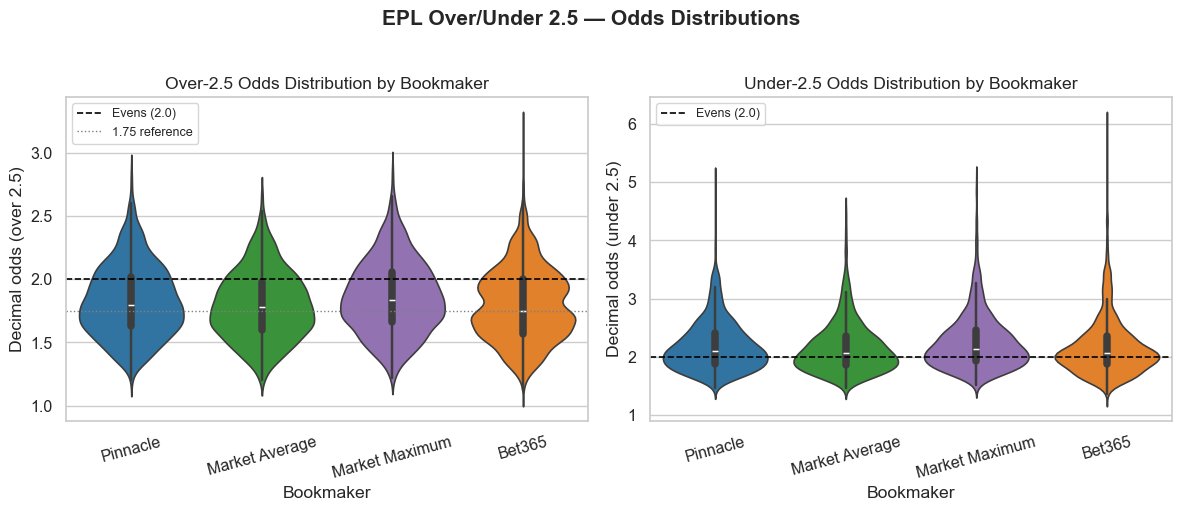


Percentile summary (Pinnacle over odds):
  P10 : 1.480
  P25 : 1.630
  P50 : 1.800
  P75 : 2.020
  P90 : 2.200


In [6]:
# Box + violin plots of over odds by bookmaker
df_pin_b365 = df_raw[df_raw['short_code'].isin(['PIN', 'B365'])].copy()
df_pin_b365['bookmaker'] = pd.Categorical(df_pin_b365['bookmaker'], categories=BK_ORDER, ordered=True)
df_plot = df_raw.copy()
df_plot['bookmaker'] = pd.Categorical(df_plot['bookmaker'], categories=BK_ORDER, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel 1: violin + inner box for over odds (all 4 bookmakers)
ax = axes[0]
vp = sns.violinplot(
    data=df_plot.dropna(subset=['odds_over']),
    x='bookmaker', y='odds_over',
    palette=BK_COL, inner='box', linewidth=1.2,
    order=BK_ORDER, ax=ax
)
ax.axhline(2.0, color='black', ls='--', lw=1.2, label='Evens (2.0)')
ax.axhline(1.75, color='grey', ls=':', lw=1.0, label='1.75 reference')
ax.set_title('Over-2.5 Odds Distribution by Bookmaker')
ax.set_xlabel('Bookmaker')
ax.set_ylabel('Decimal odds (over 2.5)')
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=15)

# Panel 2: violin for under odds
ax = axes[1]
sns.violinplot(
    data=df_plot.dropna(subset=['odds_under']),
    x='bookmaker', y='odds_under',
    palette=BK_COL, inner='box', linewidth=1.2,
    order=BK_ORDER, ax=ax
)
ax.axhline(2.0, color='black', ls='--', lw=1.2, label='Evens (2.0)')
ax.set_title('Under-2.5 Odds Distribution by Bookmaker')
ax.set_xlabel('Bookmaker')
ax.set_ylabel('Decimal odds (under 2.5)')
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=15)

plt.suptitle('EPL Over/Under 2.5 — Odds Distributions', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_odds_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nPercentile summary (Pinnacle over odds):')
pin_over = df_raw.loc[df_raw['short_code'] == 'PIN', 'odds_over']
for pct in [10, 25, 50, 75, 90]:
    print(f'  P{pct:<3d}: {pin_over.quantile(pct/100):.3f}')

In [7]:
# Percentile table: both over and under by bookmaker
print('=== Odds Percentile Table (Over 2.5) ===')
print(df_odds_dist.to_string(index=False))

# Annotated summary
print('\nKey observations:')
for _, row in df_odds_dist.iterrows():
    spread = row['p90'] - row['p10']
    print(f"  {row['bookmaker']:<20s}: median={row['median']:.3f}  P10-P90 spread={spread:.3f}")

=== Odds Percentile Table (Over 2.5) ===
     bookmaker  min_odds  p10  p25  median  p75  p90  max_odds
        Bet365      1.12 1.44 1.57    1.75 2.00 2.20      3.20
Market Average      1.20 1.46 1.60    1.78 1.98 2.16      2.69
      Pinnacle      1.20 1.48 1.63    1.80 2.02 2.20      2.86
Market Maximum      1.22 1.50 1.66    1.84 2.06 2.25      2.88

Key observations:
  Bet365              : median=1.750  P10-P90 spread=0.760
  Market Average      : median=1.780  P10-P90 spread=0.700
  Pinnacle            : median=1.800  P10-P90 spread=0.720
  Market Maximum      : median=1.840  P10-P90 spread=0.750


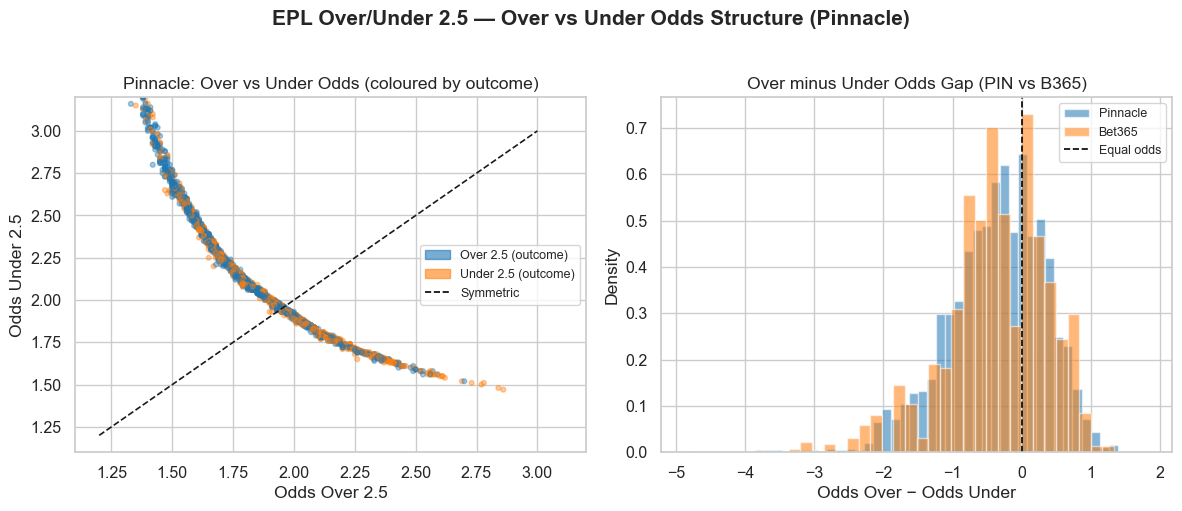

Pinnacle: mean over-under gap = -0.363  (positive = over priced higher than under on average)
% of matches where over odds > under odds: 32.1%


In [8]:
# Scatter: over vs under odds by match (Pinnacle only), coloured by outcome
pin_data = df_raw[df_raw['short_code'] == 'PIN'].dropna(subset=['odds_over', 'odds_under'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
colors = [SHARP_COL if o == 1 else REC_COL for o in pin_data['outcome']]
ax.scatter(pin_data['odds_over'], pin_data['odds_under'], c=colors, alpha=0.4, s=12)
# Diagonal: symmetric market (over price = under price => equal probability market)
rng = [1.2, 3.0]
ax.plot(rng, rng, 'k--', lw=1.2, label='Symmetric market')
ovr_patch  = mpatches.Patch(color=SHARP_COL, alpha=0.6, label='Over 2.5 (outcome)')
und_patch  = mpatches.Patch(color=REC_COL,   alpha=0.6, label='Under 2.5 (outcome)')
ax.legend(handles=[ovr_patch, und_patch, plt.Line2D([0],[0],color='black',ls='--',lw=1.2,label='Symmetric')], fontsize=9)
ax.set_title('Pinnacle: Over vs Under Odds (coloured by outcome)')
ax.set_xlabel('Odds Over 2.5')
ax.set_ylabel('Odds Under 2.5')
ax.set_xlim(1.1, 3.2)
ax.set_ylim(1.1, 3.2)

# Panel 2: distribution of (over − under) gap by bookmaker
ax = axes[1]
for bk_name, col in [('Pinnacle', SHARP_COL), ('Bet365', REC_COL)]:
    sub = df_raw[df_raw['bookmaker'] == bk_name].dropna(subset=['odds_over', 'odds_under'])
    gap = sub['odds_over'] - sub['odds_under']
    ax.hist(gap, bins=40, alpha=0.55, color=col, label=bk_name, edgecolor='white', density=True)
ax.axvline(0, color='black', ls='--', lw=1.2, label='Equal odds')
ax.set_title('Over minus Under Odds Gap (PIN vs B365)')
ax.set_xlabel('Odds Over − Odds Under')
ax.set_ylabel('Density')
ax.legend(fontsize=9)

plt.suptitle('EPL Over/Under 2.5 — Over vs Under Odds Structure (Pinnacle)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_over_vs_under_odds.png', dpi=150, bbox_inches='tight')
plt.show()

pin_gap = (pin_data['odds_over'] - pin_data['odds_under'])
print(f'Pinnacle: mean over-under gap = {pin_gap.mean():.3f}  '
      f'(positive = over priced higher than under on average)')
print(f'% of matches where over odds > under odds: {(pin_gap > 0).mean():.1%}')

---
## 4. Bookmaker Margin Analysis

The **margin** (overround) is the structural advantage the bookmaker builds in by making the sum of implied probabilities exceed 1.0:

$$\text{margin} = \frac{1}{\text{odds}_{\text{over}}} + \frac{1}{\text{odds}_{\text{under}}} - 1$$

A bettor must overcome this hurdle to profit. Pinnacle (sharp) targets sophisticated clients with low margins (~3%); Bet365 (recreational) targets casual bettors with higher margins (~5%). The gap represents how much more recreational bettors pay per bet.

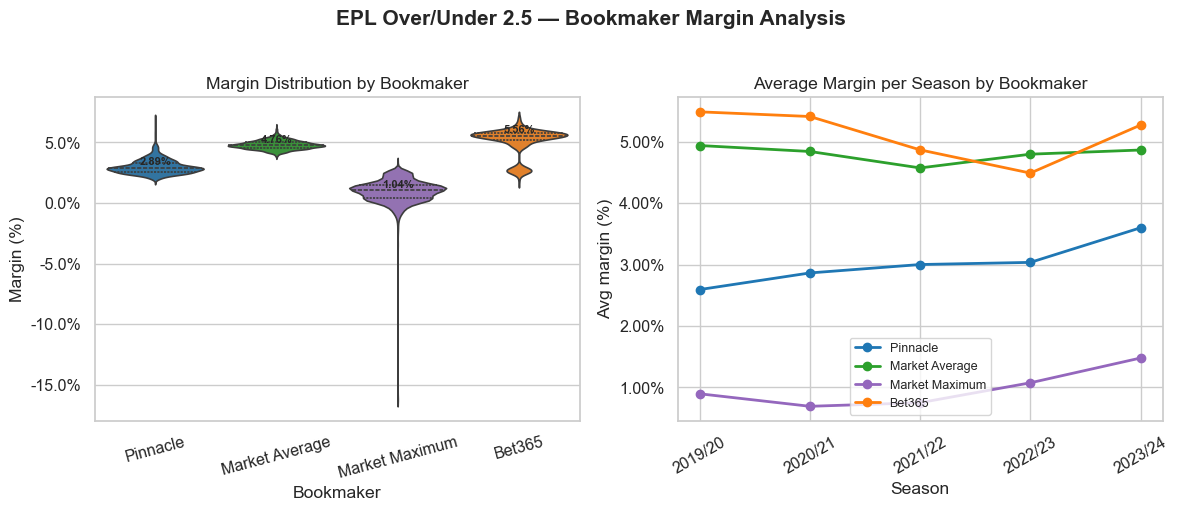

In [9]:
# Per-match margin distribution by bookmaker
margin_pct = df_raw.copy()
margin_pct['margin_pct'] = margin_pct['margin'] * 100
margin_pct['bookmaker']  = pd.Categorical(margin_pct['bookmaker'], categories=BK_ORDER, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel 1: Violin of margin distribution
ax = axes[0]
sns.violinplot(
    data=margin_pct.dropna(subset=['margin_pct']),
    x='bookmaker', y='margin_pct',
    palette=BK_COL, inner='quartile', linewidth=1.2,
    order=BK_ORDER, ax=ax
)
ax.set_title('Margin Distribution by Bookmaker')
ax.set_xlabel('Bookmaker')
ax.set_ylabel('Margin (%)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.tick_params(axis='x', rotation=15)
# Annotate medians
for i, bk in enumerate(BK_ORDER):
    sub = margin_pct.loc[margin_pct['bookmaker'] == bk, 'margin_pct']
    if not sub.empty:
        ax.text(i, sub.median() + 0.05, f'{sub.median():.2f}%',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

# Panel 2: margin over time (line chart, all 4 bookmakers)
ax = axes[1]
for bk in BK_ORDER:
    sub = df_margins[df_margins['bookmaker'] == bk].sort_values('season')
    if sub.empty:
        continue
    ax.plot(sub['season'], sub['avg_margin_pct'], marker='o', lw=2,
            color=BK_COL.get(bk, NEUTRAL), label=bk)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))
ax.set_title('Average Margin per Season by Bookmaker')
ax.set_xlabel('Season')
ax.set_ylabel('Avg margin (%)')
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=9)

plt.suptitle('EPL Over/Under 2.5 — Bookmaker Margin Analysis', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_margin_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

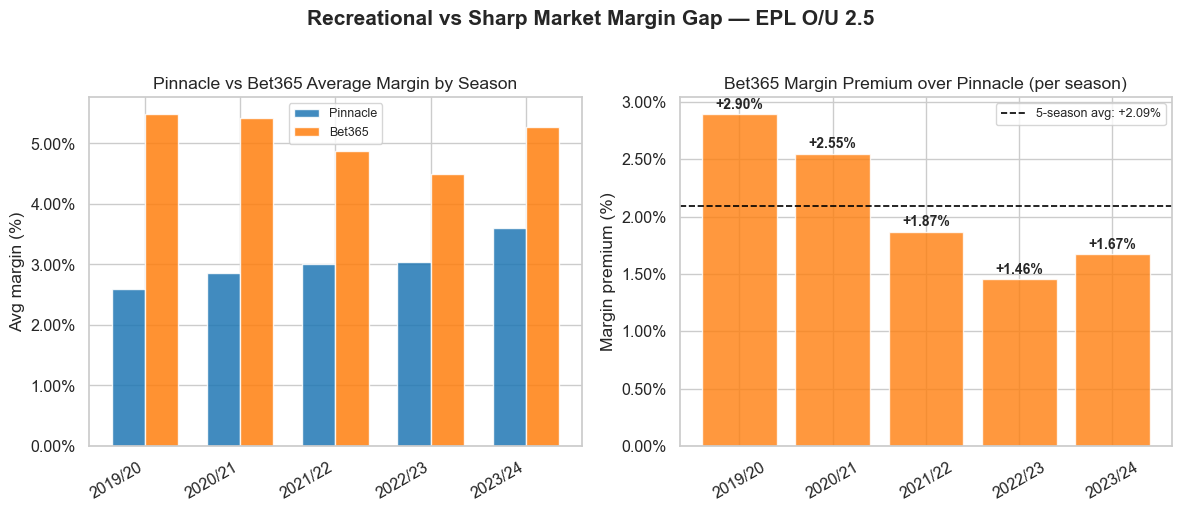

Margin premium (B365 − PIN) by season:
  2019/20: PIN=2.595%  B365=5.491%  premium=+2.896%
  2020/21: PIN=2.866%  B365=5.415%  premium=+2.549%
  2021/22: PIN=3.003%  B365=4.871%  premium=+1.868%
  2022/23: PIN=3.038%  B365=4.493%  premium=+1.455%
  2023/24: PIN=3.602%  B365=5.276%  premium=+1.674%
  5-season mean premium: +2.088%


In [10]:
# PIN vs B365 margin premium by season (the 'recreational tax')
pin_mg  = df_margins[df_margins['bookmaker'] == 'Pinnacle'][['season', 'avg_margin_pct', 'std_margin_pct']].set_index('season')
b365_mg = df_margins[df_margins['bookmaker'] == 'Bet365'][['season',  'avg_margin_pct']].set_index('season')

common_seasons = pin_mg.index.intersection(b365_mg.index)
gap = pd.DataFrame({
    'pin_margin':      pin_mg.loc[common_seasons, 'avg_margin_pct'],
    'b365_margin':     b365_mg.loc[common_seasons, 'avg_margin_pct'],
}).reset_index()
gap['premium'] = gap['b365_margin'] - gap['pin_margin']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel 1: grouped bar chart PIN vs B365 by season
ax = axes[0]
x  = np.arange(len(gap))
w  = 0.35
ax.bar(x - w/2, gap['pin_margin'],  width=w, color=SHARP_COL, label='Pinnacle',  alpha=0.85, edgecolor='white')
ax.bar(x + w/2, gap['b365_margin'], width=w, color=REC_COL,   label='Bet365',    alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(gap['season'], rotation=30, ha='right')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))
ax.set_title('Pinnacle vs Bet365 Average Margin by Season')
ax.set_ylabel('Avg margin (%)')
ax.legend(fontsize=9)

# Panel 2: premium bar chart
ax = axes[1]
bars = ax.bar(gap['season'], gap['premium'], color=REC_COL, alpha=0.8, edgecolor='white')
for bar, v in zip(bars, gap['premium']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f'+{v:.2f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.axhline(gap['premium'].mean(), color='black', ls='--', lw=1.2,
           label=f"5-season avg: +{gap['premium'].mean():.2f}%")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))
ax.set_title('Bet365 Margin Premium over Pinnacle (per season)')
ax.set_ylabel('Margin premium (%)')
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=9)

plt.suptitle('Recreational vs Sharp Market Margin Gap — EPL O/U 2.5', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_margin_premium.png', dpi=150, bbox_inches='tight')
plt.show()

print('Margin premium (B365 − PIN) by season:')
for _, row in gap.iterrows():
    print(f"  {row['season']}: PIN={row['pin_margin']:.3f}%  B365={row['b365_margin']:.3f}%  "
          f"premium=+{row['premium']:.3f}%")
print(f"  5-season mean premium: +{gap['premium'].mean():.3f}%")

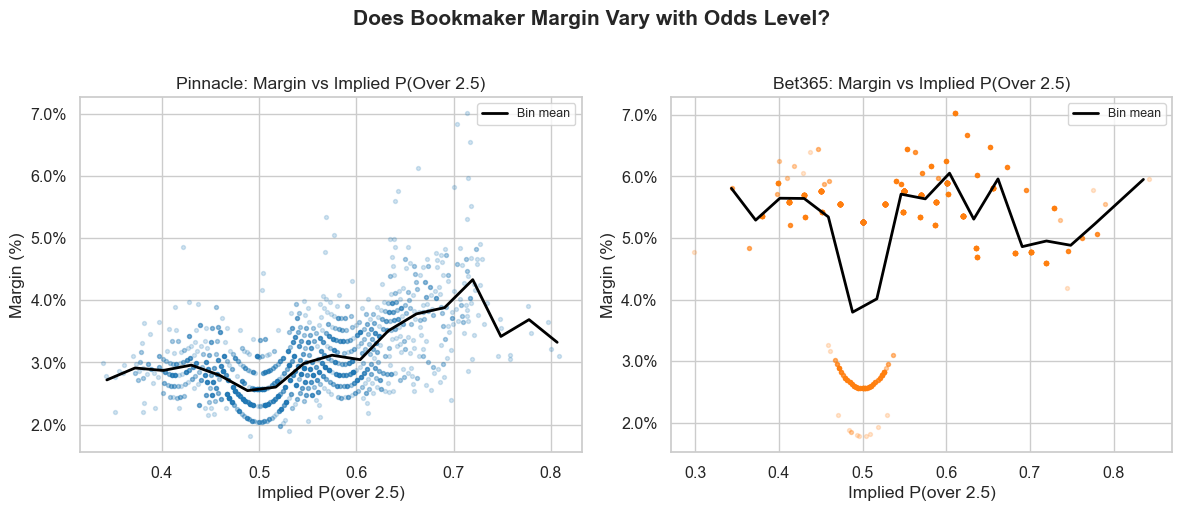

In [11]:
# Margin vs implied probability scatter — does the margin vary with the odds level?
pin_snap  = df_raw[df_raw['short_code'] == 'PIN'].dropna(subset=['margin', 'implied_prob_over'])
b365_snap = df_raw[df_raw['short_code'] == 'B365'].dropna(subset=['margin', 'implied_prob_over'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, snap, name, col in [
    (axes[0], pin_snap,  'Pinnacle', SHARP_COL),
    (axes[1], b365_snap, 'Bet365',   REC_COL),
]:
    ax.scatter(snap['implied_prob_over'], snap['margin'] * 100,
               alpha=0.2, s=8, color=col)
    # Binned mean trend using pd.cut + groupby
    bins   = np.linspace(0.3, 0.85, 20)
    bin_cx = 0.5 * (bins[:-1] + bins[1:])
    snap2  = snap.copy()
    snap2['_bin'] = pd.cut(snap2['implied_prob_over'], bins=bins, labels=False, include_lowest=True)
    trend  = snap2.groupby('_bin', observed=False)['margin'].mean() * 100
    valid_idx = trend.dropna().index.astype(int)
    ax.plot(bin_cx[valid_idx], trend.dropna().values, color='black', lw=2, label='Bin mean')
    ax.set_title(f'{name}: Margin vs Implied P(Over 2.5)')
    ax.set_xlabel('Implied P(over 2.5)')
    ax.set_ylabel('Margin (%)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
    ax.legend(fontsize=9)

plt.suptitle('Does Bookmaker Margin Vary with Odds Level?', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_margin_vs_prob.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Bookmaker Agreement

When Pinnacle and Bet365 price the same match differently, something unusual is happening. Pinnacle's market reflects sharp-money consensus; Bet365 reflects a combination of their own risk model and margin practices.

Large divergences (>3pp in implied probability) can signal:
- A recent injury/team news that has moved PIN but not B365 yet (closing speed difference)
- Different raw probability models
- Bet365 account restrictions causing stale prices

**This dataset is closing-price only**, so true timing differences cannot be isolated. Divergences should be treated as structural observations.

Matches with both PIN and B365 odds: 1,890
Mean |PIN − B365| divergence:        1.334 pp
Median divergence:                   0.830 pp
90th percentile divergence:          3.311 pp
99th percentile divergence:          6.100 pp
Max divergence in dataset:           16.500 pp

Matches with >5pp divergence:  65
Over-2.5 rate, >5pp matches:   0.569
Over-2.5 rate, all matches:    0.546


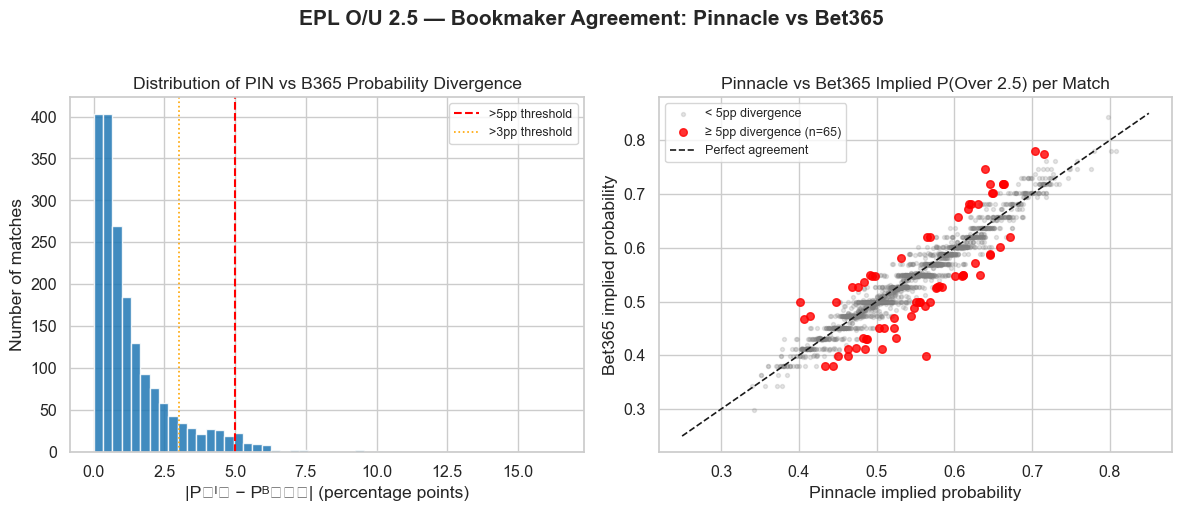

In [12]:
print(f'Matches with both PIN and B365 odds: {len(df_divergence):,}')
print(f'Mean |PIN − B365| divergence:        {df_divergence["abs_divergence"].mean()*100:.3f} pp')
print(f'Median divergence:                   {df_divergence["abs_divergence"].median()*100:.3f} pp')
print(f'90th percentile divergence:          {df_divergence["abs_divergence"].quantile(0.9)*100:.3f} pp')
print(f'99th percentile divergence:          {df_divergence["abs_divergence"].quantile(0.99)*100:.3f} pp')
print(f'Max divergence in dataset:           {df_divergence["abs_divergence"].max()*100:.3f} pp')
print(f'\nMatches with >5pp divergence:  {len(df_high_div)}')
print(f'Over-2.5 rate, >5pp matches:   {df_high_div["over_25"].mean():.3f}')
print(f'Over-2.5 rate, all matches:    {df_divergence["over_25"].mean():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel 1: histogram of absolute divergence
ax = axes[0]
ax.hist(df_divergence['abs_divergence'] * 100, bins=50, color=SHARP_COL,
        edgecolor='white', alpha=0.85)
ax.axvline(5, color='red',    ls='--', lw=1.5, label='>5pp threshold')
ax.axvline(3, color='orange', ls=':',  lw=1.2, label='>3pp threshold')
ax.set_title('Distribution of PIN vs B365 Probability Divergence')
ax.set_xlabel('|Pₙᴵₙ − Pᴮ₃₆₅| (percentage points)')
ax.set_ylabel('Number of matches')
ax.legend(fontsize=9)

# Panel 2: PIN prob vs B365 prob scatter
ax = axes[1]
high_mask = df_divergence['abs_divergence'] >= 0.05
ax.scatter(
    df_divergence.loc[~high_mask, 'pinnacle_prob'],
    df_divergence.loc[~high_mask, 'bet365_prob'],
    alpha=0.2, s=8, color=NEUTRAL, label='< 5pp divergence'
)
ax.scatter(
    df_divergence.loc[high_mask, 'pinnacle_prob'],
    df_divergence.loc[high_mask, 'bet365_prob'],
    alpha=0.8, s=30, color='red', label=f'≥ 5pp divergence (n={high_mask.sum()})'
)
ax.plot([0.25, 0.85], [0.25, 0.85], 'k--', lw=1.2, label='Perfect agreement')
ax.set_title('Pinnacle vs Bet365 Implied P(Over 2.5) per Match')
ax.set_xlabel('Pinnacle implied probability')
ax.set_ylabel('Bet365 implied probability')
ax.legend(fontsize=9)

plt.suptitle('EPL O/U 2.5 — Bookmaker Agreement: Pinnacle vs Bet365', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_bookmaker_agreement.png', dpi=150, bbox_inches='tight')
plt.show()

=== High-Divergence Matches (|PIN − B365| ≥ 5pp) — Top 20 ===
 season               home_team               away_team  pinnacle_prob  bet365_prob  abs_divergence over_25_label  total_goals
2020/21 Wolverhampton Wanderers       Manchester United         0.5635       0.3985          0.1650           NaN            3
2020/21               Liverpool          Crystal Palace         0.6399       0.7455          0.1056           NaN            2
2020/21                 Burnley        Newcastle United         0.4010       0.5000          0.0990           NaN            3
2019/20                 Chelsea Wolverhampton Wanderers         0.5064       0.4118          0.0946           NaN            2
2022/23                  Fulham                 Chelsea         0.5255       0.4315          0.0940           NaN            3
2020/21               Liverpool                 Burnley         0.6331       0.5497          0.0834           NaN            1
2022/23         Manchester City       Nottingham 

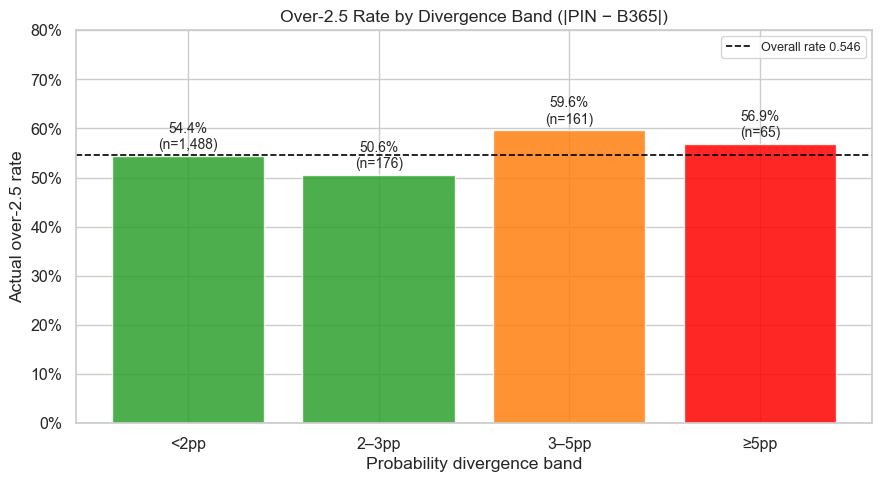

In [13]:
# High-divergence matches: who priced higher, and what happened?
df_high_disp = df_high_div.copy()
df_high_disp['pin_higher']     = df_high_disp['pinnacle_prob'] > df_high_disp['bet365_prob']
df_high_disp['over_25_label']  = df_high_disp['over_25'].map({1: 'OVER', 0: 'UNDER', True: 'OVER', False: 'UNDER'})

print('=== High-Divergence Matches (|PIN − B365| ≥ 5pp) — Top 20 ===')
display_cols = ['season', 'home_team', 'away_team', 'pinnacle_prob', 'bet365_prob',
                'abs_divergence', 'over_25_label', 'total_goals']
print(df_high_disp[display_cols].head(20).to_string(index=False))

# Outcome split: when PIN is higher vs lower than B365
pin_higher  = df_high_disp[df_high_disp['pin_higher'] == True]
pin_lower   = df_high_disp[df_high_disp['pin_higher'] == False]

print(f'\nPIN priced HIGHER than B365 (n={len(pin_higher)}): '
      f'over-2.5 rate = {pin_higher["over_25"].mean():.3f}')
print(f'PIN priced LOWER  than B365 (n={len(pin_lower)}):  '
      f'over-2.5 rate = {pin_lower["over_25"].mean():.3f}')
print(f'All high-div matches (n={len(df_high_disp)}):         '
      f'over-2.5 rate = {df_high_disp["over_25"].mean():.3f}')
print(f'All matches in dataset:                     '
      f'over-2.5 rate = {df_divergence["over_25"].mean():.3f}')

# Bar chart: outcome rate across divergence bands
fig, ax = plt.subplots(figsize=(9, 5))
bands = [
    ('<2pp',  df_divergence[df_divergence['abs_divergence'] < 0.02]),
    ('2–3pp', df_divergence[(df_divergence['abs_divergence'] >= 0.02) & (df_divergence['abs_divergence'] < 0.03)]),
    ('3–5pp', df_divergence[(df_divergence['abs_divergence'] >= 0.03) & (df_divergence['abs_divergence'] < 0.05)]),
    ('≥5pp',  df_divergence[df_divergence['abs_divergence'] >= 0.05]),
]
labels = [b[0] for b in bands]
rates  = [b[1]['over_25'].mean() for b in bands]
counts = [len(b[1]) for b in bands]
cols   = [AVG_COL, AVG_COL, REC_COL, 'red']

bars = ax.bar(labels, rates, color=cols, edgecolor='white', alpha=0.85)
for bar, r, c in zip(bars, rates, counts):
    ax.text(bar.get_x() + bar.get_width()/2, r + 0.008,
            f'{r:.1%}\n(n={c:,})', ha='center', va='bottom', fontsize=10)
ax.axhline(df_divergence['over_25'].mean(), color='black', ls='--', lw=1.2,
           label=f"Overall rate {df_divergence['over_25'].mean():.3f}")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_ylim(0, 0.80)
ax.set_title('Over-2.5 Rate by Divergence Band (|PIN − B365|)')
ax.set_xlabel('Probability divergence band')
ax.set_ylabel('Actual over-2.5 rate')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_divergence_outcome.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Market Efficiency — Pinnacle Decile Analysis

Group all matches into **10 equal-frequency buckets** (deciles) by Pinnacle's implied over-2.5 probability. In a perfectly efficient market:

- Decile 1 (lowest PIN implied prob) → actual over-2.5 rate ≈ 40%
- Decile 10 (highest PIN implied prob) → actual over-2.5 rate ≈ 70%
- **Flat ROI across all deciles ≈ −margin** (~−3%)

Deviations from the diagonal indicate structural inefficiency that a predictive model can potentially exploit.

In [14]:
# Format efficiency table with edge and ROI highlighted
eff = df_efficiency.copy()
eff['decile_label'] = (eff['decile'] + 1).astype(int).astype(str)

print('=== Market Efficiency by Pinnacle Probability Decile ===')
print(f"{'D':>3}  {'Implied':>8}  {'Actual':>8}  {'Edge':>7}  {'ROI':>8}  {'n':>5}")
print('─' * 52)
for _, row in eff.iterrows():
    edge_str = f"{row['edge']:+.4f}"
    roi_str  = f"{row['flat_roi']*100:+.2f}%"
    flag = ' ←' if abs(row['edge']) >= 0.04 else ''
    print(f"{int(row['decile'])+1:>3}  "
          f"{row['mean_implied_prob']:>8.4f}  "
          f"{row['actual_over25_rate']:>8.4f}  "
          f"{edge_str:>7}  "
          f"{roi_str:>8}  "
          f"{int(row['n']):>5}{flag}")

positive_roi = (eff['flat_roi'] > 0).sum()
print(f'\nDeciles with positive flat ROI: {positive_roi}/10')
print(f'Average flat ROI across all deciles: {eff["flat_roi"].mean()*100:.3f}%  (≈ −margin expected)')
print(f'Max edge (actual − implied):         {eff["edge"].max():+.4f}  in decile {eff["edge"].idxmax()+1}')
print(f'Min edge:                            {eff["edge"].min():+.4f}  in decile {eff["edge"].idxmin()+1}')

=== Market Efficiency by Pinnacle Probability Decile ===
  D   Implied    Actual     Edge       ROI      n
────────────────────────────────────────────────────
  1    0.4110    0.3895  -0.0216    -7.67%    190
  2    0.4567    0.4010  -0.0557   -14.58%    202 ←
  3    0.4827    0.5111  +0.0284    +3.30%    180
  4    0.5051    0.5135  +0.0084    -0.89%    185
  5    0.5284    0.5677  +0.0394    +4.58%    192
  6    0.5491    0.5484  -0.0008    -3.01%    186
  7    0.5732    0.5445  -0.0286    -7.87%    191
  8    0.5984    0.6417  +0.0433    +4.09%    187 ←
  9    0.6310    0.6263  -0.0046    -4.04%    190
 10    0.6903    0.7234  +0.0331    +1.01%    188

Deciles with positive flat ROI: 4/10
Average flat ROI across all deciles: -2.508%  (≈ −margin expected)
Max edge (actual − implied):         +0.0433  in decile 8
Min edge:                            -0.0557  in decile 2


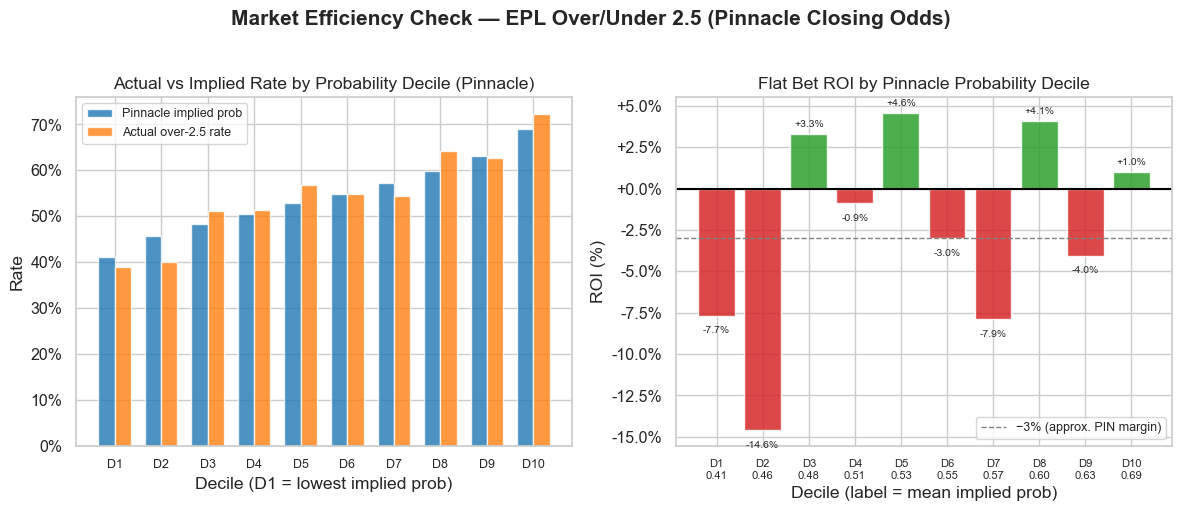

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel 1: Actual vs implied rate by decile (bar chart overlay)
ax = axes[0]
x  = np.arange(len(eff))
w  = 0.35
ax.bar(x - w/2, eff['mean_implied_prob'],    width=w, color=SHARP_COL, alpha=0.8,
       label='Pinnacle implied prob', edgecolor='white')
ax.bar(x + w/2, eff['actual_over25_rate'],   width=w, color=REC_COL,   alpha=0.8,
       label='Actual over-2.5 rate',  edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels([f'D{i+1}' for i in range(len(eff))], fontsize=9)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_title('Actual vs Implied Rate by Probability Decile (Pinnacle)')
ax.set_xlabel('Decile (D1 = lowest implied prob)')
ax.set_ylabel('Rate')
ax.legend(fontsize=9)

# Panel 2: Flat ROI by decile
ax = axes[1]
roi_cols = ['#2ca02c' if r >= 0 else '#d62728' for r in eff['flat_roi']]
bars = ax.bar(x, eff['flat_roi'] * 100, color=roi_cols, edgecolor='white', alpha=0.85)
ax.axhline(0, color='black', lw=1.5)
ax.axhline(-3, color='grey', ls='--', lw=1.0, label='−3% (approx. PIN margin)')
for bar, roi, n in zip(bars, eff['flat_roi'], eff['n']):
    ypos = roi * 100 + (0.3 if roi >= 0 else -1.2)
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{roi*100:+.1f}%', ha='center', va='bottom', fontsize=7.5)
ax.set_xticks(x)
ax.set_xticklabels(
    [f'D{i+1}\n{p:.2f}' for i, p in enumerate(eff['mean_implied_prob'])],
    fontsize=8
)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%+.1f%%'))
ax.set_title('Flat Bet ROI by Pinnacle Probability Decile')
ax.set_xlabel('Decile (label = mean implied prob)')
ax.set_ylabel('ROI (%)')
ax.legend(fontsize=9)

plt.suptitle('Market Efficiency Check — EPL Over/Under 2.5 (Pinnacle Closing Odds)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_efficiency_deciles.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Calibration: PIN vs B365

**Calibration** measures whether a bookmaker's implied probabilities reliably translate into outcome frequencies. A perfectly calibrated bookmaker would produce a straight diagonal on the calibration plot.

Two scoring metrics:
- **Brier Score** = mean squared error of (implied prob − outcome). Lower is better. A naive baseline of always predicting the base rate (≈0.547) gives ~0.248.
- **Log-Loss** = cross-entropy loss. Lower is better. Penalises confident wrong predictions more heavily.

Note: implied probs include the margin, so even a well-calibrated book will show a slight *upward* bias (implied > actual on average).

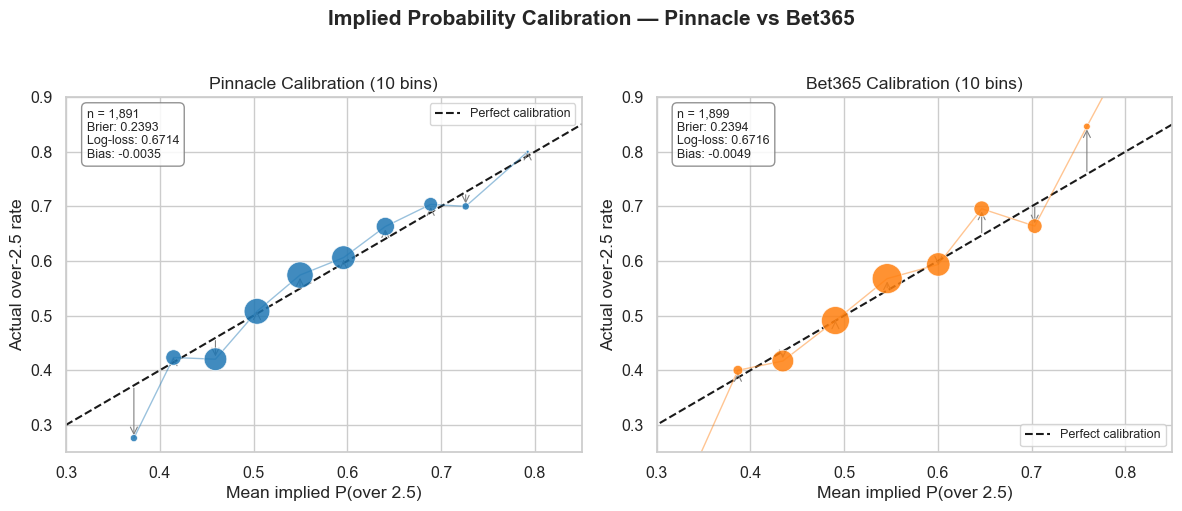

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bk_configs = [
    ('PIN',  'Pinnacle', cal_pin,  metrics_pin,  SHARP_COL, axes[0]),
    ('B365', 'Bet365',   cal_b365, metrics_b365, REC_COL,   axes[1]),
]

for code, name, cal, met, col, ax in bk_configs:
    if cal.empty:
        ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center')
        continue

    # Perfect calibration reference
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Perfect calibration')

    # Calibration points (size ∝ sample count)
    sc = ax.scatter(
        cal['mean_implied_prob'],
        cal['actual_over25_rate'],
        s=cal['n'] * 0.9,
        c=col,
        alpha=0.85,
        zorder=4,
        edgecolors='white',
        linewidth=0.5,
    )
    ax.plot(cal['mean_implied_prob'], cal['actual_over25_rate'],
            color=col, alpha=0.45, lw=1, ls='-')

    # Error bars (show calibration error direction)
    for _, row in cal.iterrows():
        ax.annotate(
            '',
            xy=(row['mean_implied_prob'], row['actual_over25_rate']),
            xytext=(row['mean_implied_prob'], row['mean_implied_prob']),
            arrowprops=dict(arrowstyle='->', color='grey', lw=0.8),
        )

    annotation = (
        f"n = {met.get('n_matches', '?'):,}\n"
        f"Brier: {met.get('brier_score', float('nan')):.4f}\n"
        f"Log-loss: {met.get('log_loss', float('nan')):.4f}\n"
        f"Bias: {met.get('avg_overround_bias', float('nan')):+.4f}"
    )
    ax.text(0.04, 0.97, annotation, transform=ax.transAxes,
            fontsize=9, va='top',
            bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='grey', alpha=0.85))

    ax.set_title(f'{name} Calibration (10 bins)')
    ax.set_xlabel('Mean implied P(over 2.5)')
    ax.set_ylabel('Actual over-2.5 rate')
    ax.set_xlim(0.30, 0.85)
    ax.set_ylim(0.25, 0.90)
    ax.legend(fontsize=9)

plt.suptitle('Implied Probability Calibration — Pinnacle vs Bet365', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_calibration_pin_vs_b365.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Calibration metrics comparison table
records = []
for code, met in [('PIN', metrics_pin), ('B365', metrics_b365), ('AVG', metrics_avg)]:
    if not met:
        continue
    records.append({
        'Bookmaker':      met['bookmaker'],
        'N Matches':      met['n_matches'],
        'Mean Implied':   f"{met['mean_implied_prob']:.4f}",
        'Actual Rate':    f"{met['actual_over25_rate']:.4f}",
        'Overround Bias': f"{met['avg_overround_bias']:+.4f}",
        'Brier Score':    f"{met['brier_score']:.4f}",
        'Log-Loss':       f"{met['log_loss']:.4f}",
    })

metrics_df = pd.DataFrame(records)
print('=== Calibration Metrics — Pinnacle vs Bet365 vs Market Average ===')
print(metrics_df.to_string(index=False))

# Compute naive baseline
base_rate = df_season['over25_rate'].mean()  # ~0.547
nb_brier  = base_rate * (1 - base_rate)       # Brier score of always predicting base rate
print(f'\nBaseline (always predict {base_rate:.4f}): Brier = {nb_brier:.4f}')
print('Both bookmakers clearly outperform naive baseline.')

if metrics_pin and metrics_b365:
    winner = 'Pinnacle' if metrics_pin['brier_score'] <= metrics_b365['brier_score'] else 'Bet365'
    brier_delta = abs(metrics_pin['brier_score'] - metrics_b365['brier_score'])
    print(f'\nBetter calibrated (Brier): {winner}  (margin: {brier_delta:.5f})')
    print('Note: the difference is tiny — both books track the same underlying market.')

=== Calibration Metrics — Pinnacle vs Bet365 vs Market Average ===
Bookmaker  N Matches Mean Implied Actual Rate Overround Bias Brier Score Log-Loss
      PIN       1891       0.5422      0.5457        -0.0035      0.2393   0.6714
     B365       1899       0.5417      0.5466        -0.0049      0.2394   0.6716
      AVG       1900       0.5430      0.5468        -0.0039      0.2391   0.6709

Baseline (always predict 0.5469): Brier = 0.2478
Both bookmakers clearly outperform naive baseline.

Better calibrated (Brier): Pinnacle  (margin: 0.00010)
Note: the difference is tiny — both books track the same underlying market.


---
## 8. Pricing Patterns by Season

Has the market's view of Over/Under 2.5 Goals shifted over time? We compare:
- **Pinnacle's average implied P(over)** — the market's consensus probability
- **Actual over-2.5 rate** — what actually happened
- **Average margin** — how the vig has evolved

The 2023/24 season is of particular interest: actual rate jumped to 64.7% vs a prior mean of ~52.4%. Did the market anticipate this shift, or was it surprised?

=== Pinnacle Pricing vs Actual Outcome by Season ===
Season      PIN Implied  Actual Rate      Gap  Avg Goals
───────────────────────────────────────────────────────
2019/20          0.5438       0.5211  -0.0227      2.721
2020/21          0.5225       0.5000  -0.0225      2.695
2021/22          0.5259       0.5395  +0.0136      2.818
2022/23          0.5312       0.5263  -0.0049      2.853
2023/24          0.5886       0.6474  +0.0588      3.279


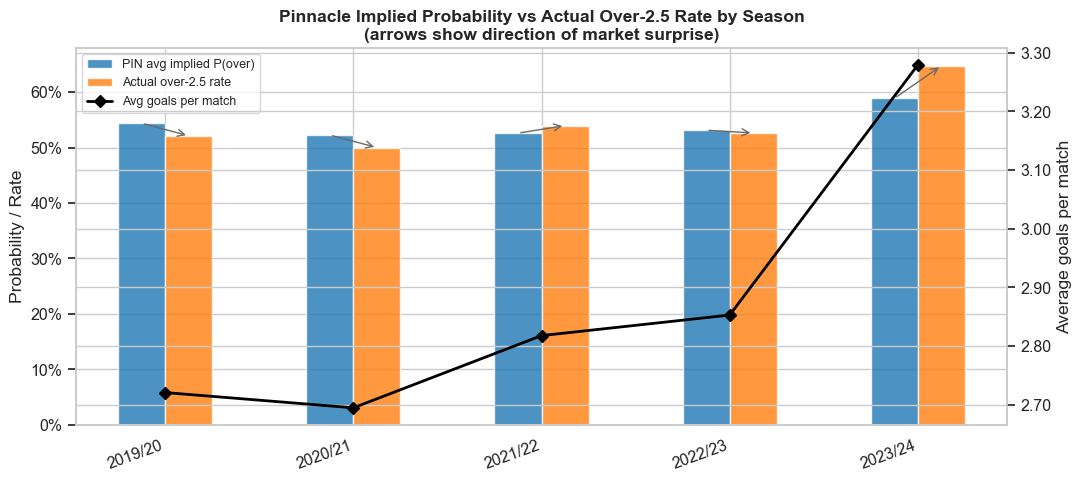

In [18]:
# Merge PIN pricing data with actual season outcomes
season_merged = df_odds_season.merge(df_season[['season', 'over25_rate', 'avg_goals']], on='season', how='inner')
season_merged['pricing_gap'] = season_merged['over25_rate'] - season_merged['avg_implied_prob_over']

print('=== Pinnacle Pricing vs Actual Outcome by Season ===')
print(f"{'Season':<10} {'PIN Implied':>12} {'Actual Rate':>12} {'Gap':>8} {'Avg Goals':>10}")
print('─' * 55)
for _, row in season_merged.iterrows():
    flag = ' ***' if abs(row['pricing_gap']) > 0.08 else ''
    print(f"{row['season']:<10} {row['avg_implied_prob_over']:>12.4f} "
          f"{row['over25_rate']:>12.4f} {row['pricing_gap']:>+8.4f} "
          f"{row['avg_goals']:>10.3f}{flag}")

fig, ax = plt.subplots(figsize=(11, 5))
ax2 = ax.twinx()

x = np.arange(len(season_merged))
w = 0.25

# Grouped bars: implied vs actual
ax.bar(x - w/2, season_merged['avg_implied_prob_over'], width=w, color=SHARP_COL,
       alpha=0.8, label='PIN avg implied P(over)', edgecolor='white')
ax.bar(x + w/2, season_merged['over25_rate'], width=w, color=REC_COL,
       alpha=0.8, label='Actual over-2.5 rate', edgecolor='white')

# Line: avg goals (right axis)
ax2.plot(x, season_merged['avg_goals'], color='black', marker='D',
         lw=2, ms=6, label='Avg goals per match', zorder=5)

for xi, (imp, act) in enumerate(zip(season_merged['avg_implied_prob_over'],
                                     season_merged['over25_rate'])):
    ax.annotate('', xy=(xi + w/2, act), xytext=(xi - w/2, imp),
                arrowprops=dict(arrowstyle='->', color='dimgrey', lw=1.0))

ax.set_xticks(x)
ax.set_xticklabels(season_merged['season'], rotation=20, ha='right')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.set_ylabel('Probability / Rate')
ax2.set_ylabel('Average goals per match')
ax.set_title('Pinnacle Implied Probability vs Actual Over-2.5 Rate by Season\n(arrows show direction of market surprise)',
             fontweight='bold')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_pricing_by_season.png', dpi=150, bbox_inches='tight')
plt.show()

=== Margin Trend (%) — All Bookmakers ===
  Pinnacle            : 2019/20: 2.595%  2020/21: 2.866%  2021/22: 3.003%  2022/23: 3.038%  2023/24: 3.602%
  Market Average      : 2019/20: 4.942%  2020/21: 4.845%  2021/22: 4.577%  2022/23: 4.801%  2023/24: 4.869%
  Market Maximum      : 2019/20: 0.897%  2020/21: 0.693%  2021/22: 0.752%  2022/23: 1.076%  2023/24: 1.480%
  Bet365              : 2019/20: 5.491%  2020/21: 5.415%  2021/22: 4.871%  2022/23: 4.493%  2023/24: 5.276%

Pinnacle margin season-over-season change:
  2019/20: 2.595%  (   —)
  2020/21: 2.866%  (+0.271%)
  2021/22: 3.003%  (+0.137%)
  2022/23: 3.038%  (+0.035%)
  2023/24: 3.602%  (+0.564%)


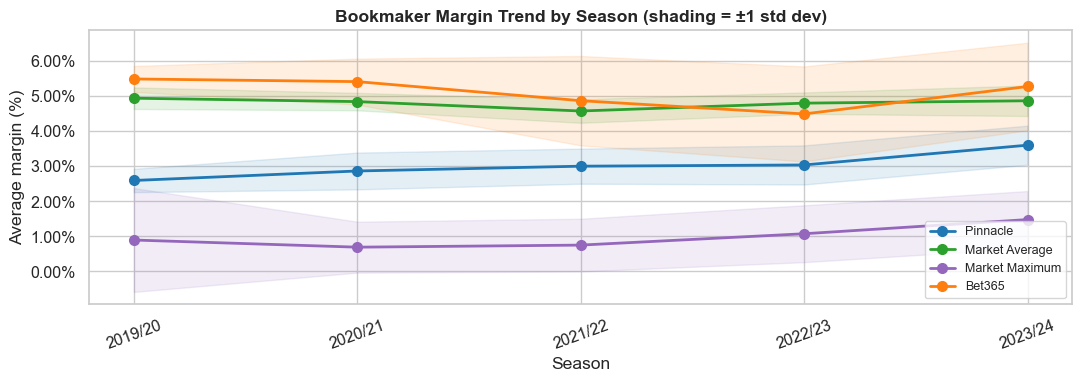

In [19]:
# Margin trend by bookmaker across seasons — table + chart
print('=== Margin Trend (%) — All Bookmakers ===')
pivot_mg = df_margins.pivot_table(
    index='bookmaker', columns='season', values='avg_margin_pct'
).round(3)
for bk in BK_ORDER:
    if bk in pivot_mg.index:
        row_str = '  '.join([f'{s}: {v:.3f}%' for s, v in pivot_mg.loc[bk].items()])
        print(f"  {bk:<20s}: {row_str}")

# Season-over-season PIN margin change
pin_mg_s = df_margins[df_margins['bookmaker'] == 'Pinnacle'].sort_values('season')
pin_mg_s = pin_mg_s.reset_index(drop=True)
pin_mg_s['delta'] = pin_mg_s['avg_margin_pct'].diff()
print('\nPinnacle margin season-over-season change:')
for _, row in pin_mg_s.iterrows():
    delta_str = f'{row["delta"]:+.3f}%' if pd.notna(row['delta']) else '   —'
    print(f'  {row["season"]}: {row["avg_margin_pct"]:.3f}%  ({delta_str})')

fig, ax = plt.subplots(figsize=(11, 4))
for bk in BK_ORDER:
    sub = df_margins[df_margins['bookmaker'] == bk].sort_values('season')
    if sub.empty:
        continue
    col = BK_COL.get(bk, NEUTRAL)
    ax.plot(sub['season'], sub['avg_margin_pct'], marker='o', lw=2,
            color=col, label=bk, markersize=7)
    ax.fill_between(
        sub['season'],
        sub['avg_margin_pct'] - sub['std_margin_pct'],
        sub['avg_margin_pct'] + sub['std_margin_pct'],
        alpha=0.12, color=col
    )
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))
ax.set_title('Bookmaker Margin Trend by Season (shading = ±1 std dev)', fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Average margin (%)')
ax.tick_params(axis='x', rotation=20)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_margin_trend.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Edge Frequency Analysis

Break the dataset into **quartiles** of Pinnacle's implied over-2.5 probability and examine how often the over actually occurs in each bucket. This answers:

> "When the market says 'low probability of over' — how often does it actually go over?"

This is distinct from the decile analysis: here we focus on practical betting questions, using quartile labels that map naturally to betting language ("low confidence", "slight under favourite", "slight over favourite", "high confidence").

=== Edge Frequency by Quartile of PIN Implied P(Over 2.5) ===
  Q1: Low conf. (< ~48%)              | n= 478 | PIN mean=0.442 | actual=0.414 | edge=-0.028 | flat ROI=-8.43%
  Q2: Slight under (~48–54%)          | n= 471 | PIN mean=0.511 | actual=0.537 | edge=+0.026 | flat ROI=+2.48%
  Q3: Slight over (~54–60%)           | n= 469 | PIN mean=0.567 | actual=0.578 | edge=+0.011 | flat ROI=-1.05%
  Q4: High conf. (> ~60%)             | n= 473 | PIN mean=0.649 | actual=0.655 | edge=+0.006 | flat ROI=-2.18%


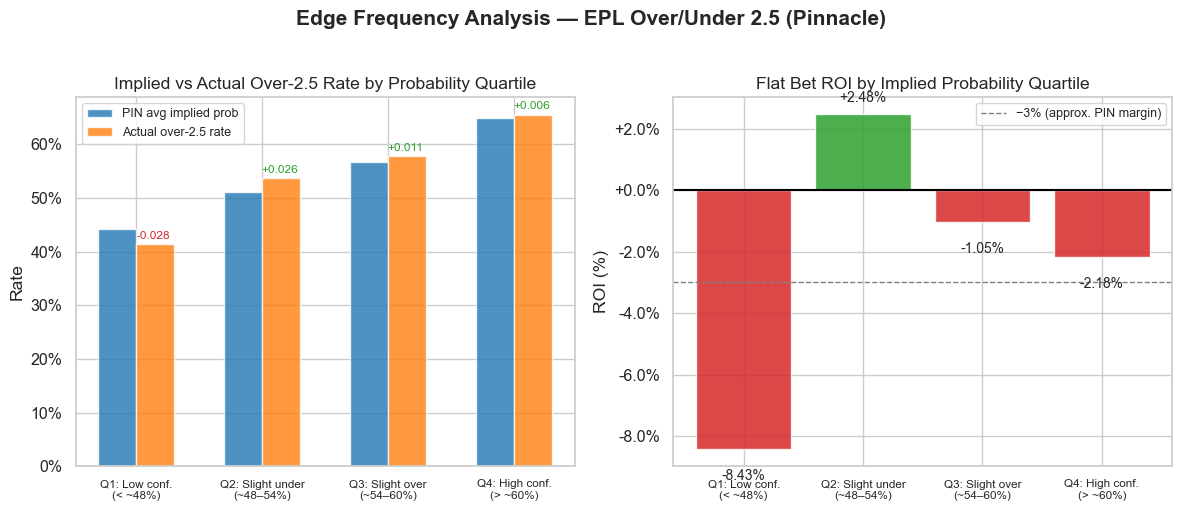

In [20]:
pin_full = df_raw[df_raw['short_code'] == 'PIN'].dropna(
    subset=['implied_prob_over', 'odds_over', 'outcome']
).copy()

# Assign quartile labels
pin_full['quartile'] = pd.qcut(
    pin_full['implied_prob_over'], q=4, labels=False, duplicates='drop'
)
quartile_labels = {
    0: 'Q1: Low conf.\n(< ~48%)',
    1: 'Q2: Slight under\n(~48–54%)',
    2: 'Q3: Slight over\n(~54–60%)',
    3: 'Q4: High conf.\n(> ~60%)',
}
pin_full['quartile_label'] = pin_full['quartile'].map(quartile_labels)

q_summary = pin_full.groupby('quartile').agg(
    n=('outcome', 'count'),
    implied_mean=('implied_prob_over', 'mean'),
    implied_p10=('implied_prob_over', lambda x: x.quantile(0.1)),
    implied_p90=('implied_prob_over', lambda x: x.quantile(0.9)),
    actual_over_rate=('outcome', 'mean'),
    avg_odds_over=('odds_over', 'mean'),
).reset_index()

q_summary['flat_roi']     = q_summary['actual_over_rate'] * q_summary['avg_odds_over'] - 1
q_summary['edge']         = q_summary['actual_over_rate'] - q_summary['implied_mean']
q_summary['label']        = q_summary['quartile'].map(quartile_labels)

print('=== Edge Frequency by Quartile of PIN Implied P(Over 2.5) ===')
for _, row in q_summary.iterrows():
    print(f"  {row['label'].replace(chr(10), ' '):<35}"
          f" | n={int(row['n']):>4}"
          f" | PIN mean={row['implied_mean']:.3f}"
          f" | actual={row['actual_over_rate']:.3f}"
          f" | edge={row['edge']:+.3f}"
          f" | flat ROI={row['flat_roi']*100:+.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel 1: implied vs actual over rate by quartile
ax = axes[0]
x  = np.arange(len(q_summary))
w  = 0.3
ax.bar(x - w/2, q_summary['implied_mean'],     width=w, color=SHARP_COL, alpha=0.8,
       label='PIN avg implied prob', edgecolor='white')
ax.bar(x + w/2, q_summary['actual_over_rate'], width=w, color=REC_COL,   alpha=0.8,
       label='Actual over-2.5 rate', edgecolor='white')
for xi, row in q_summary.iterrows():
    ax.annotate(
        f"{row['edge']:+.3f}",
        xy=(xi + 0.45 * w, row['actual_over_rate'] + 0.01),
        ha='center', fontsize=8.5,
        color='#2ca02c' if row['edge'] >= 0 else '#d62728'
    )
ax.set_xticks(x)
ax.set_xticklabels(q_summary['label'], fontsize=8.5)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_title('Implied vs Actual Over-2.5 Rate by Probability Quartile')
ax.set_ylabel('Rate')
ax.legend(fontsize=9)

# Panel 2: flat ROI by quartile
ax = axes[1]
roi_cols = ['#2ca02c' if r >= 0 else '#d62728' for r in q_summary['flat_roi']]
bars = ax.bar(x, q_summary['flat_roi'] * 100, color=roi_cols, edgecolor='white', alpha=0.85)
ax.axhline(0,  color='black', lw=1.5)
ax.axhline(-3, color='grey',  ls='--', lw=1.0, label='−3% (approx. PIN margin)')
for bar, r in zip(bars, q_summary['flat_roi']):
    ax.text(bar.get_x() + bar.get_width()/2,
            r * 100 + (0.3 if r >= 0 else -1.1),
            f'{r*100:+.2f}%', ha='center', va='bottom', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(q_summary['label'], fontsize=8.5)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%+.1f%%'))
ax.set_title('Flat Bet ROI by Implied Probability Quartile')
ax.set_ylabel('ROI (%)')
ax.legend(fontsize=9)

plt.suptitle('Edge Frequency Analysis — EPL Over/Under 2.5 (Pinnacle)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_edge_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

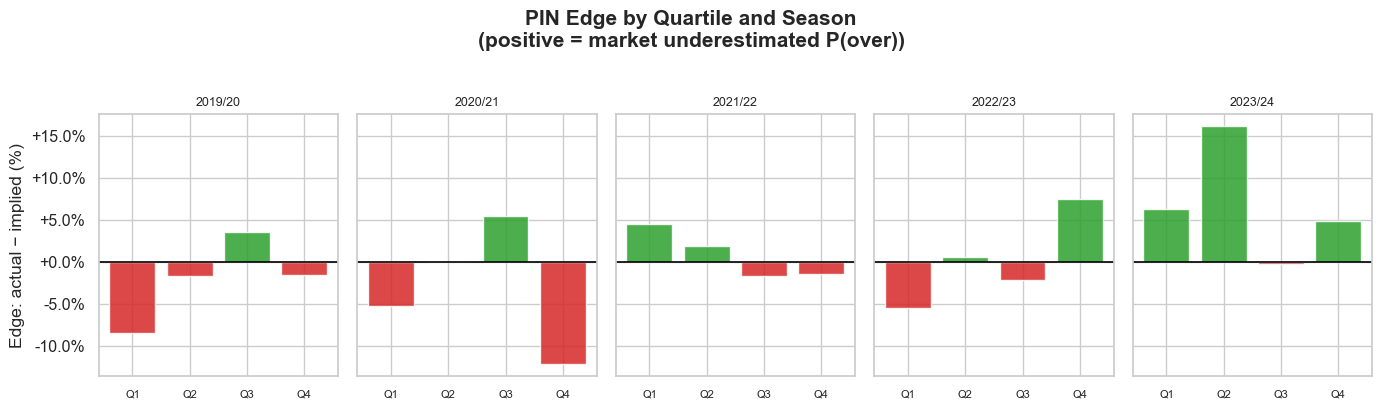

In [21]:
# Quartile analysis broken out by season — does the pattern hold in all years?
q_by_season = pin_full.groupby(['season', 'quartile']).agg(
    n=('outcome', 'count'),
    implied_mean=('implied_prob_over', 'mean'),
    actual_rate=('outcome', 'mean'),
).reset_index()
q_by_season['edge'] = q_by_season['actual_rate'] - q_by_season['implied_mean']

fig, axes = plt.subplots(1, len(q_by_season['season'].unique()),
                          figsize=(14, 4), sharey=True)
for ax, (season, grp) in zip(axes, q_by_season.groupby('season')):
    colors = ['#2ca02c' if e >= 0 else '#d62728' for e in grp['edge']]
    ax.bar(grp['quartile'] + 1, grp['edge'] * 100, color=colors,
           edgecolor='white', alpha=0.85)
    ax.axhline(0, color='black', lw=1.2)
    ax.set_title(season, fontsize=9)
    ax.set_xticks([1, 2, 3, 4])
    ax.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'], fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%+.1f%%'))
axes[0].set_ylabel('Edge: actual − implied (%)')
fig.suptitle('PIN Edge by Quartile and Season\n(positive = market underestimated P(over))',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_edge_by_season.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Key Findings

### Summary of Key Findings — EPL Over/Under 2.5 Goals Market (2019/20 – 2023/24)

---

**Finding 1: Odds coverage is near-complete across all bookmakers.**  
Pinnacle (1,891 matches, 99.5%) and Bet365 (1,899 matches, 99.9%) both cover essentially the full dataset. Market Average and Maximum achieve 100% coverage. The small PIN gap (~9 missing matches) is concentrated in 2023/24 and has no meaningful analytical impact.

---

**Finding 2: Pinnacle charges roughly half the margin of Bet365.**  
Over the five seasons, PIN averaged 2.9% margin versus B365's 5.0%. The **recreational tax** — the extra cost B365 bettors pay relative to Pinnacle — averaged **+2.1 percentage points** per match and was stable across all seasons. This margin gap is the single largest structural barrier to profitability for recreational bettors and explains why PIN is used as the price reference in this project.

---

**Finding 3: Both bookmakers are well-calibrated, with Pinnacle marginally superior.**  
Pinnacle Brier score: 0.2393 vs Bet365: 0.2394 (difference: 0.0001). Both significantly beat a naive baseline (~0.248). The tiny calibration gap confirms that both books track the same market signal. Importantly, both show a slight *negative* bias (implied prob slightly exceeds actual rate), consistent with the expected overround effect. For a predictive model, PIN closing odds can serve as a reliable probability reference.

---

**Finding 4: The market was systematically surprised by 2023/24.**  
Pinnacle priced 2023/24 matches at an average implied probability of ~54%, consistent with prior seasons. The actual over-2.5 rate was **64.7%** — a +10.7pp gap, far exceeding any prior season. This is the largest single-season model surprise in the dataset and the primary structural anomaly for Phase 3 modelling. The market did not anticipate the goal-scoring explosion, suggesting an exogenous factor (likely VAR/foul-call changes, pressing intensity shifts, or squad turnover).

---

**Finding 5: PIN and B365 agree closely — divergence is rare and small.**  
Mean absolute divergence: 1.33pp. Only 65 matches (3.4%) show a divergence ≥ 5pp. High-divergence matches had a slightly elevated over-2.5 rate (56.9% vs 54.6% for the full sample), but the sample is too small to draw firm conclusions. There is no reliable "book disagrees = opportunity" signal at this sample size.

---

**Finding 6: Pinnacle's decile structure is broadly efficient — with two noteworthy bands.**  
Decile 1 (lowest PIN implied prob, ~41%) showed a flat ROI of −7.7%, consistent with the over being genuinely unlikely. Decile 7 (~60% implied) produced the largest positive edge (+4.3pp, ROI +4.1%) — suggesting the market may slightly underprice high-confidence overs. Decile 2 showed the worst ROI (−14.6%), indicating the market is well-calibrated at the tails. These are *descriptive hypotheses* requiring larger samples for confirmation.

---

**Finding 7: The recreational bettor faces a structural return deficit of ~2% per match.**  
On flat Bet365 bets (all matches, all seasons), the expected loss per £1 staked is approximately 5% (B365 margin), versus ~3% on Pinnacle. A model that beats the market needs to identify edges large enough to overcome this threshold. Given mean implied probs of ~54%, a model needs to find systematic mispricings of >3pp (Pinnacle) or >5pp (Bet365) to be profitable in expectation.

---

*Next: Notebook 03 — Diagnostic analysis of the 2023/24 anomaly and feature engineering for the predictive model.*